In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# Task 1

In [40]:
class_counts = df["target"].value_counts().sort_index()

class_rate = df["target"].value_counts(
    normalize=True
).sort_index() * 100

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_rate.round(2)
})

class_summary.index = [
    "Income <= 50K (Negative)",
    "Income > 50K (Positive)"
]

class_summary

,Count,Percentage
Income <= 50K (Negative),37155,76.07
Income > 50K (Positive),11687,23.93


In [41]:
positive_base_rate = df["target"].mean() * 100

print(
    f"Positive class base rate: "
    f"{positive_base_rate:.2f}%"
)

Positive class base rate: 23.93%


# Task 2

In [23]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = adult.frame.copy()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [24]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [25]:
print("Dataset shape:", df.shape)

Dataset shape: (48842, 15)


In [26]:
print("Columns:")
print(df.columns.tolist())

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']


In [27]:
df.dtypes

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
class             category
dtype: object

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [29]:
print(df["class"].value_counts())

class
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [30]:
# Convert the Target to Binary
df["target"] = (
    df["class"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
    .map({
        "<=50K": 0,
        ">50K": 1
    })
)

# Drop original target column
df.drop(columns=["class"], inplace=True)

print(df["target"].value_counts())

target
0    37155
1    11687
Name: count, dtype: int64


In [31]:
assert df["target"].isna().sum() == 0

print("Target successfully converted to binary!")

Target successfully converted to binary!


In [32]:
# Strip whitespace from string columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

In [33]:
df.replace("?", np.nan, inplace=True)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


In [34]:
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0]

print(missing_values.sort_values(ascending=False))

occupation        2809
workclass         2799
native-country     857
dtype: int64


In [35]:
print("Total missing values:", df.isna().sum().sum())

Total missing values: 6465


In [36]:
# Basic EDA

In [37]:
print("Shape:", df.shape)

print("\nData Types:")
display(df.dtypes.value_counts())

Shape: (48842, 15)

Data Types:


int64       7
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
Name: count, dtype: int64

In [38]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove target from feature summary
numeric_features = [col for col in numeric_cols if col != "target"]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [39]:
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(categorical_cols)

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [42]:
# Visualizations

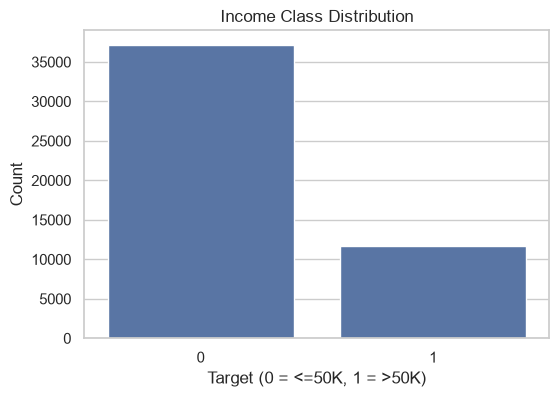

In [43]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Income Class Distribution")
plt.xlabel("Target (0 = <=50K, 1 = >50K)")
plt.ylabel("Count")

plt.show()

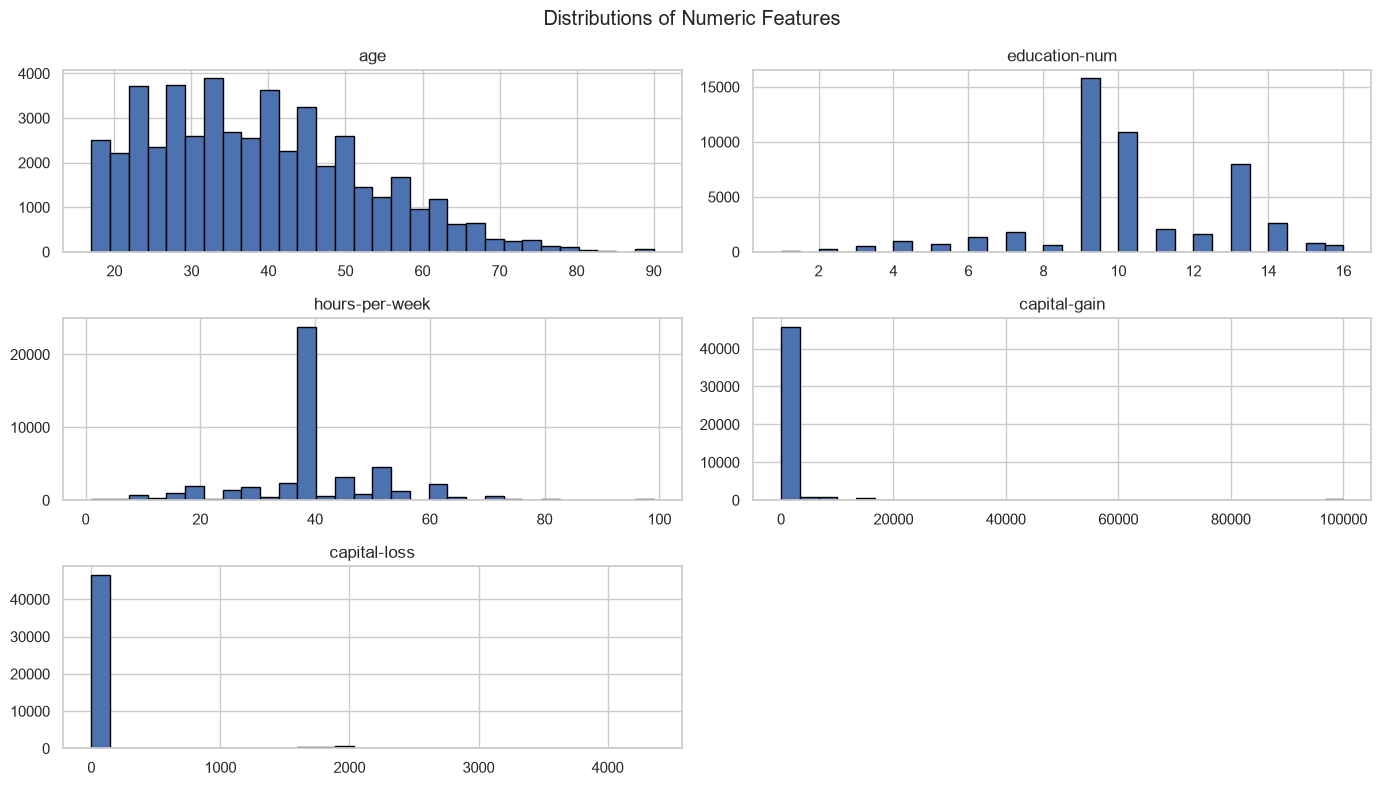

In [44]:
features_to_plot = [
    "age",
    "education-num",
    "hours-per-week",
    "capital-gain",
    "capital-loss"
]

df[features_to_plot].hist(
    figsize=(14, 8),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distributions of Numeric Features")
plt.tight_layout()
plt.show()

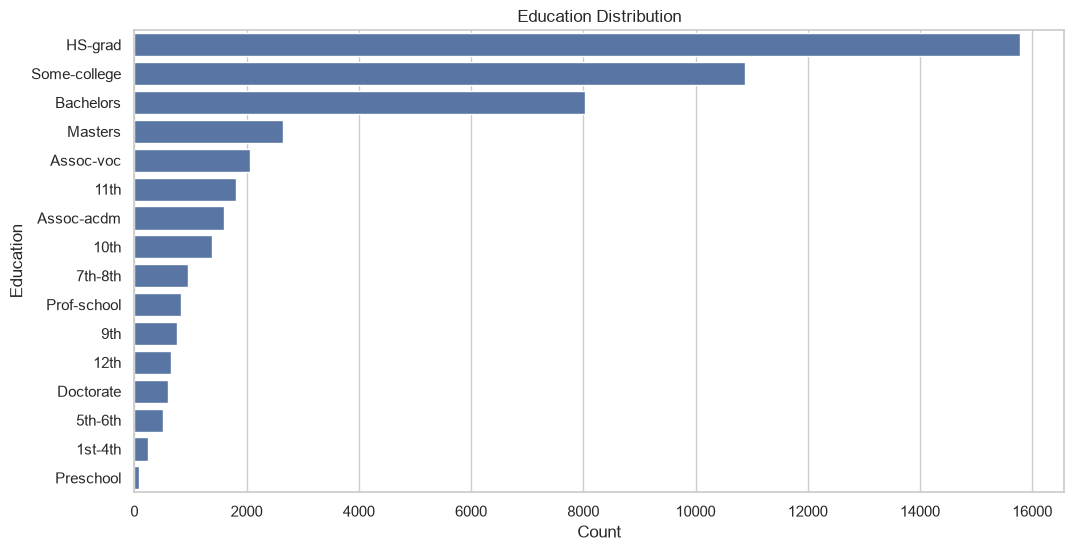

In [45]:
plt.figure(figsize=(12, 6))

education_order = df["education"].value_counts().index

sns.countplot(
    data=df,
    y="education",
    order=education_order
)

plt.title("Education Distribution")
plt.xlabel("Count")
plt.ylabel("Education")

plt.show()

In [46]:
# EDA Summary Table

In [47]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Samples",
        "Negative Class (<=50K)",
        "Positive Class (>50K)",
        "Positive Class Rate (%)",
        "Median Age",
        "Median Hours per Week",
        "Mean Education Number",
        "People with Capital Gain > 0 (%)"
    ],
    "Value": [
        len(df),
        int((df["target"] == 0).sum()),
        int((df["target"] == 1).sum()),
        round(df["target"].mean() * 100, 2),
        round(df["age"].median(), 2),
        round(df["hours-per-week"].median(), 2),
        round(df["education-num"].mean(), 2),
        round((df["capital-gain"] > 0).mean() * 100, 2)
    ]
})

eda_summary

,Metric,Value
0,Total Samples,48842.00
1,Negative Class (<=50K),37155.00
2,Positive Class (>50K),11687.00
3,Positive Class Rate (%),23.93
4,Median Age,37.00
5,Median Hours per Week,40.00
6,Mean Education Number,10.08
7,People with Capital Gain > 0 (%),8.26


# Task 3

In [76]:
X = df.drop(columns=["target"])
y = df["target"]

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

In [78]:
print("Training set:", X_train.shape)
print("Hold-out test set:", X_test.shape)

Training set: (39073, 14)
Hold-out test set: (9769, 14)


In [79]:
print("Overall positive rate:")
print(y.mean())

print("\nTrain positive rate:")
print(y_train.mean())

print("\nTest positive rate:")
print(y_test.mean())

Overall positive rate:
0.23928176569346055

Train positive rate:
0.23927008420136667

Test positive rate:
0.23932848807452145


In [80]:
# Optional Dev Split

In [81]:
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    stratify=y_train,
    random_state=RANDOM_STATE
)

In [82]:
print("Training set:", X_train.shape)
print("Development set:", X_dev.shape)
print("Test set:", X_test.shape)

Training set: (35165, 14)
Development set: (3908, 14)
Test set: (9769, 14)


# Task 4

In [83]:
# Baseline 1: Majority-Class Predictor

In [84]:
majority_class = y_train.mode()[0]

print("Majority class:", majority_class)

Majority class: 0


In [85]:
y_pred_majority = np.full(
    shape=len(y_test),
    fill_value=majority_class
)

In [86]:
majority_score = y_train_dev.mean()

y_score_majority = np.full(
    shape=len(y_test),
    fill_value=majority_score
)

In [87]:
def evaluate_model(
    y_true,
    y_pred,
    y_score,
    model_name
):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC AUC": roc_auc_score(
            y_true,
            y_score
        ),
        "PR AUC": average_precision_score(
            y_true,
            y_score
        )
    }

In [88]:
majority_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_majority,
    y_score=y_score_majority,
    model_name="Majority Class Baseline"
)

majority_results

{'Model': 'Majority Class Baseline',
 'Accuracy': 0.7606715119254785,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC AUC': 0.5,
 'PR AUC': 0.23932848807452145}

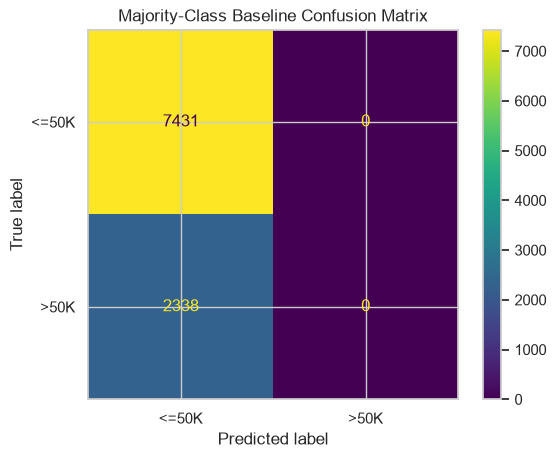

In [89]:
cm_majority = confusion_matrix(
    y_test,
    y_pred_majority
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_majority,
    display_labels=[
        "<=50K",
        ">50K"
    ]
)

disp.plot()
plt.title("Majority-Class Baseline Confusion Matrix")
plt.show()

In [90]:
# Baseline 2 — Rule-Based Classifier

In [91]:
education_income = pd.crosstab(
    df["education-num"],
    df["target"],
    normalize="index"
)

education_income

target,0,1
education-num,,
1,0.987952,0.012048
2,0.967611,0.032389
3,0.946955,0.053045
4,0.935079,0.064921
5,0.945767,0.054233
6,0.937365,0.062635
7,0.949227,0.050773
8,0.926941,0.073059
9,0.841422,0.158578


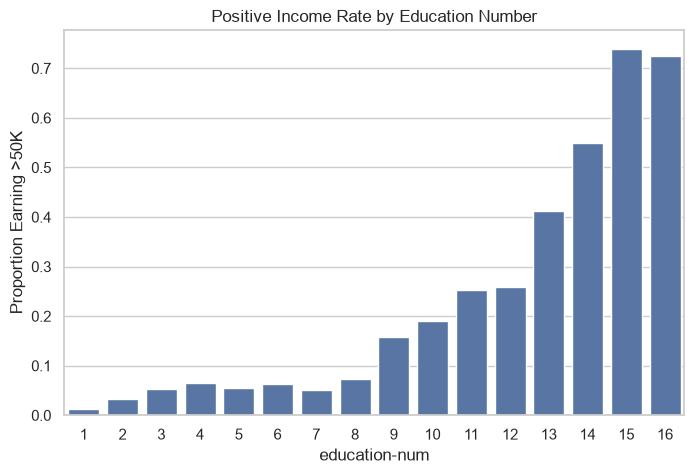

In [92]:
education_positive_rate = (
    df.groupby("education-num")["target"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=education_positive_rate,
    x="education-num",
    y="target"
)

plt.title(
    "Positive Income Rate by Education Number"
)

plt.ylabel("Proportion Earning >50K")

plt.show()

In [93]:
y_pred_rule = (
    X_test["education-num"] >= 13
).astype(int)

In [94]:
y_score_rule = X_test["education-num"].astype(float)

In [95]:
rule_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_rule,
    y_score=y_score_rule,
    model_name="Education Rule Baseline"
)

rule_results

{'Model': 'Education Rule Baseline',
 'Accuracy': 0.7529941652165012,
 'Precision': 0.484368486869529,
 'Recall': 0.49700598802395207,
 'F1': 0.4906058686932658,
 'ROC AUC': 0.7188632712083187,
 'PR AUC': 0.44425843100241386}

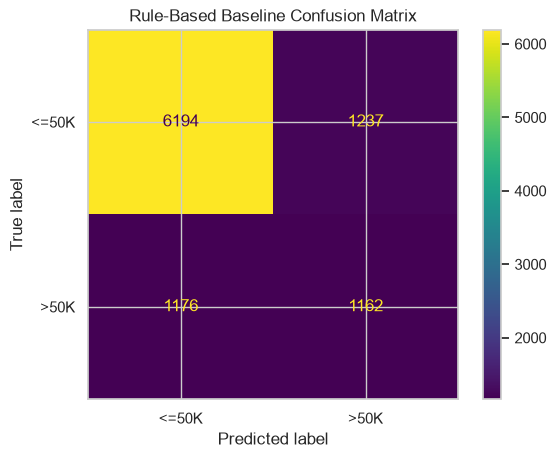

In [96]:
cm_rule = confusion_matrix(
    y_test,
    y_pred_rule
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rule,
    display_labels=[
        "<=50K",
        ">50K"
    ]
)

disp.plot()
plt.title("Rule-Based Baseline Confusion Matrix")
plt.show()

In [98]:
# Final Metrics Table
results_df = pd.DataFrame([
    majority_results,
    rule_results
])

results_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,Majority Class Baseline,0.760672,0.000000,0.000000,0.000000,0.500000,0.239328
1,Education Rule Baseline,0.752994,0.484368,0.497006,0.490606,0.718863,0.444258


### Baseline Interpretation

The Education Rule Baseline is the more useful baseline because, although its accuracy (75.30%) is slightly lower than the Majority Class Baseline (76.07%), it is actually able to identify high-income individuals. It achieved a precision of 48.44%, recall of 49.70%, F1-score of 49.06%, ROC AUC of 71.89%, and PR AUC of 44.43%, while the Majority Class Baseline achieved zero precision, recall, and F1 because it predicted every individual as the negative class. The high accuracy of the majority baseline is therefore misleading and mainly reflects the class imbalance in the dataset, where only 23.93% of individuals belong to the positive class. A real machine learning model should at minimum outperform the Education Rule Baseline's 48.44% precision and improve its overall ability to identify and rank high-income individuals.

# Task 5

In [99]:
error_analysis = X_test.copy()

error_analysis["actual"] = y_test.values
error_analysis["predicted"] = y_pred_rule.values

error_analysis.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,actual,predicted
40342,54,Private,115602,HS-grad,9,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,40,United-States,0,0
47680,28,Local-gov,401886,HS-grad,9,Never-married,Adm-clerical,Other-relative,White,Male,0,0,20,United-States,0,0
524,53,Local-gov,139671,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,0,0
8508,58,Private,177368,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,3137,0,16,United-States,0,0
31692,47,Local-gov,352614,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,0


In [100]:
false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1)
]

print(
    "Number of False Positives:",
    len(false_positives)
)

false_positives.sample(
    min(10, len(false_positives)),
    random_state=RANDOM_STATE
)

Number of False Positives: 1237


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,actual,predicted
9079,34,Private,110622,Bachelors,13,Never-married,Adm-clerical,Unmarried,Asian-Pac-Islander,Female,0,0,40,Philippines,0,1
43504,76,Federal-gov,25319,Masters,14,Widowed,Prof-specialty,Not-in-family,White,Female,0,0,15,United-States,0,1
26569,41,Self-emp-inc,397280,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,72,NaN,0,1
26634,33,Private,126414,Bachelors,13,Married-civ-spouse,Other-service,Wife,White,Female,0,0,40,NaN,0,1
44063,41,Private,222504,Prof-school,15,Divorced,Prof-specialty,Unmarried,White,Female,0,0,38,United-States,0,1
25654,40,Private,224799,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,45,United-States,0,1
32137,47,Self-emp-not-inc,208407,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,2002,30,United-States,0,1
30212,46,Self-emp-not-inc,154083,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,25,United-States,0,1
45307,23,NaN,190650,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,0,1
13246,33,Private,369258,Bachelors,13,Never-married,Handlers-cleaners,Other-relative,White,Female,0,0,40,Mexico,0,1


In [101]:
false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0)
]

print(
    "Number of False Negatives:",
    len(false_negatives)
)

false_negatives.sample(
    min(10, len(false_negatives)),
    random_state=RANDOM_STATE
)

Number of False Negatives: 1176


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,actual,predicted
425,39,Private,177140,HS-grad,9,Separated,Adm-clerical,Not-in-family,White,Male,0,0,40,United-States,1,0
24544,52,Private,213209,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,1,0
23437,36,Private,284166,HS-grad,9,Never-married,Sales,Unmarried,White,Male,0,0,60,United-States,1,0
35719,58,NaN,266792,Some-college,10,Married-civ-spouse,NaN,Husband,White,Male,99999,0,40,United-States,1,0
10564,37,Private,166115,10th,6,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,50,United-States,1,0
38489,35,Self-emp-not-inc,462832,HS-grad,9,Married-civ-spouse,Craft-repair,Wife,Black,Female,0,0,40,United-States,1,0
6470,38,Private,98776,Some-college,10,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,1,0
47261,55,Local-gov,296085,Assoc-acdm,12,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,40,United-States,1,0
3205,31,Private,336543,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,0,0,45,United-States,1,0
17353,37,Private,215310,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,1,0


In [102]:
comparison_features = [
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

print("FALSE POSITIVES:")
display(
    false_positives[
        comparison_features
    ].describe().T
)

print("\nFALSE NEGATIVES:")
display(
    false_negatives[
        comparison_features
    ].describe().T
)

FALSE POSITIVES:


,count,mean,std,min,25%,50%,75%,max
age,1237.0,37.229588,12.432432,21.0,27.0,34.0,44.0,90.0
education-num,1237.0,13.305578,0.642666,13.0,13.0,13.0,13.0,16.0
capital-gain,1237.0,196.113177,874.446492,0.0,0.0,0.0,0.0,6849.0
capital-loss,1237.0,61.839935,325.257732,0.0,0.0,0.0,0.0,2258.0
hours-per-week,1237.0,40.145513,12.324030,1.0,40.0,40.0,45.0,99.0



FALSE NEGATIVES:


,count,mean,std,min,25%,50%,75%,max
age,1176.0,44.073129,10.806527,22.0,36.0,43.0,51.0,90.0
education-num,1176.0,9.540816,1.379498,2.0,9.0,10.0,10.0,12.0
capital-gain,1176.0,2780.892857,11342.033678,0.0,0.0,0.0,0.0,99999.0
capital-loss,1176.0,157.984694,539.663285,0.0,0.0,0.0,0.0,3004.0
hours-per-week,1176.0,45.035714,10.465770,2.0,40.0,40.0,50.0,99.0


In [103]:
print("False Positive Occupations:")
display(
    false_positives[
        "occupation"
    ].value_counts().head(10)
)

False Positive Occupations:


occupation
Prof-specialty      428
Exec-managerial     224
Sales               163
Adm-clerical        141
Tech-support         57
Other-service        48
Craft-repair         43
Transport-moving     23
Farming-fishing      18
Protective-serv      18
Name: count, dtype: int64

In [104]:
print("False Negative Occupations:")
display(
    false_negatives[
        "occupation"
    ].value_counts().head(10)
)

False Negative Occupations:


occupation
Craft-repair         258
Exec-managerial      203
Sales                160
Prof-specialty        93
Adm-clerical          89
Transport-moving      88
Machine-op-inspct     62
Tech-support          54
Protective-serv       39
Other-service         37
Name: count, dtype: int64

In [105]:
print("False Positive Marital Status:")
display(
    false_positives[
        "marital-status"
    ].value_counts(normalize=True).head(10)
)

False Positive Marital Status:


marital-status
Never-married            0.480194
Married-civ-spouse       0.287793
Divorced                 0.151981
Widowed                  0.031528
Separated                0.027486
Married-spouse-absent    0.021019
Married-AF-spouse        0.000000
Name: proportion, dtype: float64

In [106]:
print("False Negative Marital Status:")
display(
    false_negatives[
        "marital-status"
    ].value_counts(normalize=True).head(10)
)

False Negative Marital Status:


marital-status
Married-civ-spouse       0.875000
Never-married            0.051020
Divorced                 0.050170
Widowed                  0.010204
Married-spouse-absent    0.006803
Separated                0.005102
Married-AF-spouse        0.001701
Name: proportion, dtype: float64

## Error Analysis Findings

The error analysis shows that the simple education-based rule makes a substantial number of mistakes: 1,237 false positives and 1,176 false negatives. False positives had a mean age of approximately 37 years and were all predicted as high income because their education number was at least 13; however, many of them had zero capital gain and worked across occupations such as professional specialty, executive managerial, sales, and administrative roles. Nearly 48% of false positives were never married, suggesting that education alone does not capture other factors associated with income.

False negatives were generally older, with a mean age of approximately 44 years, and worked more hours per week on average (45 hours compared with approximately 40 hours for false positives). Their education number was below the rule threshold, with an average of 9.54, yet they still earned more than $50K; many belonged to occupations such as craft repair, executive managerial, and sales, and 87.5% were married to a civilian spouse. Some false negatives also had substantial capital gains, demonstrating that the education-only rule ignores important income-related information beyond educational attainment.

# Data and Feature Issues to Address Next

1. **Missing categorical values:** The dataset contains missing values in `occupation`, `workclass`, and `native-country`, so an appropriate imputation strategy is required.

2. **Categorical feature encoding:** Most potentially useful features are categorical and must be encoded before they can be used by many machine learning algorithms.

3. **Overly simple feature rule:** The current baseline uses only `education-num`, while the error analysis shows that age, occupation, marital status, hours worked, and capital gains may also provide useful predictive information.

4. **Skewed capital features:** `capital-gain` and `capital-loss` contain many zero values and extreme values, so their distributions should be investigated and potentially transformed.

5. **Class imbalance:** Only 23.93% of observations belong to the positive class, making accuracy insufficient as the main performance measure.

6. **Potential redundant features:** `education` and `education-num` represent closely related information and should be examined for redundancy during feature engineering and model development.

# Primary Metric for the Rest of the Week

For the remainder of the week, **precision** will be the primary metric because the business objective is to reduce wasted outreach by ensuring that individuals predicted to earn more than $50K are likely to actually belong to the high-income group. The Education Rule Baseline achieved a precision of **48.44%**, meaning that fewer than half of its positive predictions were correct, which leaves significant room for improvement. Future models should therefore aim to improve precision beyond 48.44% while monitoring recall to ensure that improvements in precision do not come at the cost of missing too many genuinely high-income individuals. ROC AUC and PR AUC will also be tracked as supporting metrics to evaluate the model's overall ranking performance.